In [1]:
from qiskit_nature.second_q.hamiltonians import HeisenbergModel
from qiskit_nature.second_q.hamiltonians.lattices import line_lattice
from qiskit_nature.second_q.mappers import LogarithmicMapper
from qiskit import QuantumCircuit
nqb = 5
line = line_lattice.LineLattice(nqb)
H = LogarithmicMapper().map(HeisenbergModel(line, (1,1,1)).second_q_op())
print(H)
Hmat = H.to_matrix()

SparsePauliOp(['IIIXX', 'IIIYY', 'IIIZZ', 'IIXXI', 'IIYYI', 'IIZZI', 'IXXII', 'IYYII', 'IZZII', 'XXIII', 'YYIII', 'ZZIII'],
              coeffs=[0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j,
 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j])


In [2]:
import numpy as np 
e,v = np.linalg.eigh(Hmat)
gs_id = np.argsort(e)[:2]
gs_1 = v[:, gs_id[0]]
gs_2 = v[:, gs_id[1]]

In [3]:
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator

def sample_haar_su2():
    alpha = np.random.uniform(0, 2 * np.pi)
    u     = np.random.uniform(0, 1)
    beta  = 2 * np.arccos(np.sqrt(u))   # absorbs sin(β) Jacobian
    gamma = np.random.uniform(0, 2 * np.pi)
    return alpha, beta, gamma

gs_1_sv = Statevector(gs_1)
gs_2_sv = Statevector(gs_2)

mixed_state = 0.5 * np.outer(gs_1, gs_1.conj()) + 0.5 * np.outer(gs_2, gs_2.conj())
mixed_distance = []
mixed_unnorm = np.zeros([2**nqb, 2**nqb], dtype = complex)
energies = []
for t in range(1001):
    random_su2 = QuantumCircuit(nqb)
    alpha, beta, gamma = sample_haar_su2()
    for i in range(nqb):
        random_su2.rz(gamma, i)
        random_su2.ry(beta, i)
        random_su2.rz(alpha, i)
    test_mat = Operator(random_su2).data
    assert(np.allclose(test_mat @ Hmat - Hmat @ test_mat, np.zeros([2**nqb, 2**nqb])))
    gs_t = gs_1_sv.evolve(random_su2).data
    mixed_unnorm += np.outer(gs_t, gs_t.conj())
    energies.append(np.trace(Hmat @ np.outer(gs_t, gs_t.conj())))
    mixed_distance.append(np.linalg.norm(mixed_state - mixed_unnorm/np.complex128(t+1)))

Text(0.5, 0, 'samples')

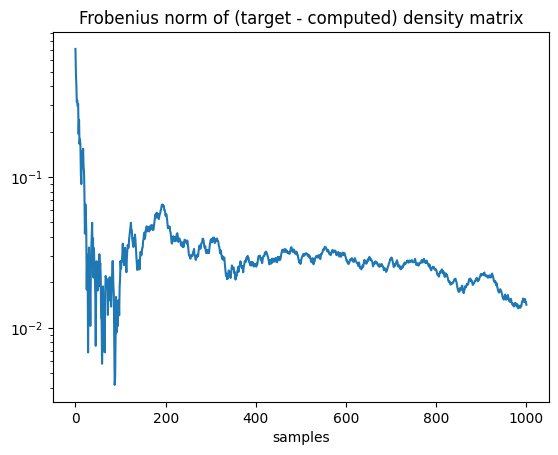

In [4]:
import matplotlib.pyplot as plt
plt.semilogy(mixed_distance)
plt.title('Frobenius norm of (target - computed) density matrix')
plt.xlabel('samples')


1. find commuting cliques

2. find U that diagonalizes each commuting clique

3. Measure U|\psi>

4. reconstruct <\psi|P|\psi> 

5. reconstruct <\psi|H|\psi>

In [5]:
from pathlib import Path
import sys
project_root = Path("/Users/asaad/Documents/Algolabs/Liouville-Lanczos").resolve()
pauliarray_repo = project_root / "pauliarray"

# Remove stale paths that may point to the wrong level
sys.path = [
    p for p in sys.path
    if "pauliarray-main" not in p
]

# Put the actual pauliarray repo first
sys.path.insert(0, str(pauliarray_repo))

In [6]:
def greedy_commuting_cliques(paulis):
    n = len(paulis.to_labels())
    unused = set(range(n))
    cliques = []

    while unused:
        clique = []

        for i in list(unused):
            compatible = True

            for j in clique:
                ok = bool(paulis[i].commute_with(paulis[j]))

                if not ok:
                    compatible = False
                    break

            if compatible:
                clique.append(i)

        for i in clique:
            unused.remove(i)

        cliques.append(clique)

    return cliques

def diagonalize_general_commuting_clique(paulis, clique):
    """
    Diagonalize a general commuting clique of Pauli strings using Clifford gates.

    Parameters
    ----------
    paulis:
        A PauliArray containing all Pauli strings.

    clique:
        A list of integer indices selecting one commuting clique.
        Example: clique = general_cliques[0]

    Returns
    -------
    qc:
        A Qiskit QuantumCircuit implementing the Clifford transformation.

    transformed_clique:
        The full clique after symbolic Clifford conjugation using PauliArray.

    transformed_generators:
        The independent generators after symbolic Clifford conjugation.

    phases:
        Phase factors accumulated from transforming the full clique.
        These are important later when reconstructing signs.
    """

    # ------------------------------------------------------------
    # 1. Extract the clique from the big PauliArray.
    #    This is a PauliArray operation.
    # ------------------------------------------------------------
    clique_paulis = paulis[clique].copy()

    # ------------------------------------------------------------
    # 2. Get independent generators for the commuting clique.
    #    Also a PauliArray operation.
    #
    #    Example:
    #       {XX, YY, ZZ}
    #    has only two independent generators because XX * YY ~ ZZ.
    # ------------------------------------------------------------
    generators = clique_paulis.generators()

    # Number of qubits in the Pauli strings.
    n_qubits = clique_paulis.num_qubits

    # Qiskit circuit that stores the gates we discover.
    qc = QuantumCircuit(n_qubits)

    # These are the symbolic Pauli strings we update using PauliArray.
    transformed_clique = clique_paulis.copy()
    transformed_generators = generators.copy()

    # Track phases/signs for the full clique.
    phases = np.ones(transformed_clique.shape, dtype=complex)

    # Keep track of which qubits we have already used as pivots.
    used_pivots = set()

    # ------------------------------------------------------------
    # Helper functions.
    # Each one does TWO things:
    #
    #   1. update the Pauli strings using PauliArray
    #   2. append the same gate to the Qiskit circuit
    #
    # ------------------------------------------------------------

    def apply_h(q):
        nonlocal transformed_clique, transformed_generators, phases

        q = int(q)

        # PauliArray symbolic update
        transformed_clique, f1 = transformed_clique.h(q, inplace=False)
        transformed_generators, _ = transformed_generators.h(q, inplace=False)

        # Accumulate phases for the full clique
        phases *= f1

        # Qiskit circuit update
        qc.h(q)


    def apply_s(q):
        nonlocal transformed_clique, transformed_generators, phases

        q = int(q)

        # PauliArray symbolic update
        transformed_clique, f1 = transformed_clique.s(q, inplace=False)
        transformed_generators, _ = transformed_generators.s(q, inplace=False)

        # Accumulate phases for the full clique
        phases *= f1

        # Qiskit circuit update
        qc.s(q)


    def apply_cx(c, t):
        nonlocal transformed_clique, transformed_generators, phases

        c = int(c)
        t = int(t)

        # PauliArray expects lists/arrays of controls and targets.
        # That is why we pass [c], [t], not c, t.
        transformed_clique, f1 = transformed_clique.cx([c], [t], inplace=False)
        transformed_generators, _ = transformed_generators.cx([c], [t], inplace=False)

        phases *= f1

        qc.cx(c, t)



    def apply_cz(c, t):
        nonlocal transformed_clique, transformed_generators, phases

        c = int(c)
        t = int(t)

        # Again: PauliArray wants list-like qubit inputs.
        transformed_clique, f1 = transformed_clique.cz([c], [t], inplace=False)
        transformed_generators, _ = transformed_generators.cz([c], [t], inplace=False)

        phases *= f1

        qc.cz(c, t)


    # ------------------------------------------------------------
    # 3. Main diagonalization loop.
    #
    # We repeatedly pick one non-diagonal generator and turn it
    # into a single Z on a pivot qubit.
    #
    # A Pauli string is diagonal iff it contains only I and Z.
    # So it is non-diagonal if it contains X or Y.
    # ------------------------------------------------------------

    max_steps = 10 * n_qubits * max(1, generators.size)
    step = 0

    while not np.all(transformed_generators.is_diagonal()):
        step += 1

        if step > max_steps:
            raise RuntimeError(
                "Diagonalization did not converge. "
                "The simple pivot algorithm got stuck."
            )

        # Which generators still contain X or Y?
        non_diag = np.where(~transformed_generators.is_diagonal())[0]

        # Pick the first non-diagonal generator.
        row = int(non_diag[0])


        # Find qubits where this generator has X support.
        # In binary symplectic representation:
        #
        #   I: x=0, z=0
        #   X: x=1, z=0
        #   Z: x=0, z=1
        #   Y: x=1, z=1
        #
        # So X or Y means x_strings[row, q] == True.
        x_positions = np.where(transformed_generators.x_strings[row])[0]

        # Try to avoid reusing old pivot qubits.
        fresh_x_positions = [int(q) for q in x_positions if int(q) not in used_pivots]

        if len(fresh_x_positions) == 0:
            # If we cannot find a fresh pivot, use any X/Y position.
            # This makes the function less likely to crash for small examples.
            candidate_positions = [int(q) for q in x_positions]

            if len(candidate_positions) == 0:
                raise RuntimeError(
                    "Found a non-diagonal generator with no X/Y support. "
                    "This should not happen."
                )

            pivot = candidate_positions[0]
        else:
            pivot = fresh_x_positions[0]

        used_pivots.add(pivot)

        # --------------------------------------------------------
        # If the pivot is Y, turn it into X using S.
        #
        # Y has x=1,z=1.
        # Applying S maps Y to +/- X depending on convention.
        # The phase is tracked by PauliArray.
        # --------------------------------------------------------
        if (
            transformed_generators.x_strings[row, pivot]
            and transformed_generators.z_strings[row, pivot]
        ):
            apply_s(pivot)

        # --------------------------------------------------------
        # Clear X support on other qubits.
        #
        # Use CX(pivot -> q) to combine X support onto the pivot.
        # This is symbolic Clifford Gaussian elimination.
        # --------------------------------------------------------
        for q in range(n_qubits):
            if q == pivot:
                continue

            if transformed_generators.x_strings[row, q]:
                apply_cx(pivot, q)

        # --------------------------------------------------------
        # Clear Z support on other qubits.
        #
        # Use CZ(pivot, q) to remove extra Z factors from the
        # current generator.
        # --------------------------------------------------------
        for q in range(n_qubits):
            if q == pivot:
                continue

            if transformed_generators.z_strings[row, q]:
                apply_cz(pivot, q)

        # --------------------------------------------------------
        # After the CX/CZ cleanup, the current generator should be
        # something like X_pivot. If it is Y_pivot, convert Y to X.
        # --------------------------------------------------------
        if (
            transformed_generators.x_strings[row, pivot]
            and transformed_generators.z_strings[row, pivot]
        ):
            apply_s(pivot)

        # --------------------------------------------------------
        # Finally convert X_pivot to Z_pivot.
        #
        # H X H = Z.
        # --------------------------------------------------------
        if transformed_generators.x_strings[row, pivot]:
            apply_h(pivot)

    # ------------------------------------------------------------
    # 4. Final safety check.
    # ------------------------------------------------------------
    if not np.all(transformed_clique.is_diagonal()):
        raise RuntimeError(
            "Generators became diagonal, but the full clique did not. "
            "This should not happen for a commuting clique generated by those generators."
        )

    return qc, transformed_clique, transformed_generators, phases

In [7]:
def expval_diagonal_pauli_from_counts(counts, diagonal_label):
    """
    Estimate <Z-string> from measurement counts.

    diagonal_label example: 'IIIZZ', 'IZIZI', etc.
    """
    total = 0
    shots = 0

    for bitstring, count in counts.items():
        value = 1

        for pos, p in enumerate(diagonal_label):
            if p == "Z":
                value *= bit_to_eigenvalue(bitstring[pos])
            elif p == "I":
                pass
            else:
                raise ValueError(f"Expected only I/Z, got {p} in {diagonal_label}")

        total += count * value
        shots += count

    return total / shots

In [8]:
def pauliarray_to_labels(arr):
    return list(arr.to_labels())

def bit_to_eigenvalue(bit):
    return +1 if bit == "0" else -1

def build_measurement_circuit_for_clique(psi_circuit, paulis, clique):
    qc_diag, transformed_clique, transformed_generators, phases = diagonalize_general_commuting_clique(
        paulis,
        clique
    )

    meas_qc = psi_circuit.copy()
    meas_qc.compose(qc_diag, inplace=True)
    meas_qc.measure_all()

    return meas_qc, transformed_clique, phases

In [9]:
def reconstruct_clique_expectations(counts, clique, labels, transformed_clique, phases):
    """
    Returns dictionary:
        original Pauli label -> estimated <P>
    """
    transformed_labels = pauliarray_to_labels(transformed_clique)

    expvals = {}

    for local_idx, global_idx in enumerate(clique):
        original_label = labels[global_idx]
        diagonal_label = transformed_labels[local_idx]

        diag_expval = expval_diagonal_pauli_from_counts(counts, diagonal_label)

        # PauliArray tracks possible signs/phases from Clifford conjugation.
        # For Hermitian Pauli strings this should be real, usually ±1.
        phase = phases[local_idx]

        original_expval = phase * diag_expval

        expvals[global_idx] = original_expval


    return expvals

In [10]:
from pauliarray import PauliArray

labels = list(H.paulis.to_labels())
coeffs = np.array(H.coeffs)
paulis = PauliArray.from_labels(labels)
general_cliques = greedy_commuting_cliques(paulis)
psi_circuit = QuantumCircuit(5)


psi_circuit.h(0)
psi_circuit.cx(0, 1)


In [11]:
for k, clique in enumerate(general_cliques):

    qc, transformed_clique, transformed_generators, phases = diagonalize_general_commuting_clique(
        paulis,
        clique,
    )

In [12]:
from qiskit_aer import AerSimulator

backend = AerSimulator()
shots = 10000

all_expvals = {}

for k, clique in enumerate(general_cliques):
    print(f"\n=== Measuring clique {k} ===")

    meas_qc, transformed_clique, phases = build_measurement_circuit_for_clique(
        psi_circuit,
        paulis,
        clique,
    )

    job = backend.run(meas_qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    clique_expvals = reconstruct_clique_expectations(
        counts,
        clique,
        labels,
        transformed_clique,
        phases,
    )

    all_expvals.update(clique_expvals)


=== Measuring clique 0 ===

=== Measuring clique 1 ===


In [13]:
psi = Statevector.from_instruction(psi_circuit)
psi_vec = psi.data

def exact_pauli_expval_from_label(psi_vec, label):
    P = SparsePauliOp([label], coeffs=[1.0]).to_matrix()
    return np.vdot(psi_vec, P @ psi_vec)

exact_expvals = {}

for i, label in enumerate(labels):
    val = exact_pauli_expval_from_label(psi_vec, label)
    exact_expvals[i] = val
    print(f"{i:2d}: {label}  exact <P> = {val.real:+.8f} {val.imag:+.8f}j")



exact_energy = np.vdot(psi_vec, Hmat @ psi_vec)

print("Exact <H> =", exact_energy)

 0: IIIXX  exact <P> = +1.00000000 +0.00000000j
 1: IIIYY  exact <P> = -1.00000000 +0.00000000j
 2: IIIZZ  exact <P> = +1.00000000 +0.00000000j
 3: IIXXI  exact <P> = +0.00000000 +0.00000000j
 4: IIYYI  exact <P> = +0.00000000 +0.00000000j
 5: IIZZI  exact <P> = +0.00000000 +0.00000000j
 6: IXXII  exact <P> = +0.00000000 +0.00000000j
 7: IYYII  exact <P> = +0.00000000 +0.00000000j
 8: IZZII  exact <P> = +1.00000000 +0.00000000j
 9: XXIII  exact <P> = +0.00000000 +0.00000000j
10: YYIII  exact <P> = +0.00000000 +0.00000000j
11: ZZIII  exact <P> = +1.00000000 +0.00000000j
Exact <H> = (0.7499999999999998+0j)


In [14]:
energy = 0.0 + 0.0j

for i, coeff in enumerate(coeffs):
    energy += coeff * all_expvals[i]

print("Estimated <H> =", energy)
print("Real part =", energy.real)

Estimated <H> = (0.7402+0j)
Real part = 0.7402


In [16]:
from pathlib import Path

from inner_haar_sampler import GeneralCommutingPauliSampler as inner

state = QuantumCircuit(5)

# Example only:
state.h(0)
state.cx(0, 1)

observable = H


estimator = inner(4000)
'''
inner_prod = inner_product_haar_sampler(state, estimator, epsilon=1e-3)

A = SparsePauliOp(["IIIXX"], coeffs=[1.0])
B = SparsePauliOp(["IIIII"], coeffs=[1.0])

AB = inner_prod(A,B)
'''





'\ninner_prod = inner_product_haar_sampler(state, estimator, epsilon=1e-3)\n\nA = SparsePauliOp(["IIIXX"], coeffs=[1.0])\nB = SparsePauliOp(["IIIII"], coeffs=[1.0])\n\nAB = inner_prod(A,B)\n'

In [17]:
def sample_haar_su2():
    alpha = np.random.uniform(0, 2 * np.pi)
    u = np.random.uniform(0, 1)
    beta = 2 * np.arccos(np.sqrt(u))
    gamma = np.random.uniform(0, 2 * np.pi)
    return alpha, beta, gamma


def random_global_su2_circuit(nqb):
    """
    Build U = u ⊗ u ⊗ ... ⊗ u,
    where u is one Haar-random SU(2) rotation.
    """
    qc = QuantumCircuit(nqb)

    alpha, beta, gamma = sample_haar_su2()

    for i in range(nqb):
        qc.rz(gamma, i)
        qc.ry(beta, i)
        qc.rz(alpha, i)

    return qc


def exact_numpy_haar_inner_product(
    state: QuantumCircuit,
    A: SparsePauliOp,
    B: SparsePauliOp,
    num_haar_samples: int = 1001,
    seed: int | None = None,
):
    """
    Compute the Haar-averaged inner product exactly using dense matrices:

        average_t <psi_t| A B† + B† A |psi_t>

    where

        |psi_t> = U_t |psi>

    and U_t is a random global SU(2) rotation.
    """

    if seed is not None:
        np.random.seed(seed)

    nqb = state.num_qubits

    # Prepare original statevector |psi>
    psi = Statevector.from_instruction(state).data

    # Build f = A B† + B† A
    Bc = B.adjoint()
    f = A @ Bc + Bc @ A

    # Convert f to dense matrix
    Fmat = f.to_matrix()

    out = 0.0 + 0.0j

    for _ in range(num_haar_samples):
        # Build random global SU(2)
        U_circ = random_global_su2_circuit(nqb)

        # Convert to dense matrix
        U = Operator(U_circ).data

        # Rotate the state: |psi_t> = U |psi>
        psi_t = U @ psi

        # Compute <psi_t|F|psi_t>
        val_t = np.vdot(psi_t, Fmat @ psi_t)

        out += val_t

    return out / num_haar_samples


In [18]:
'''
value_numpy = exact_numpy_haar_inner_product(
    state=state,
    A=A,
    B=B,
    num_haar_samples=5001,
    seed=123,
)
print("numpy exact =", value_numpy)
print(AB)

print(np.absolute(value_numpy - AB))
'''


'\nvalue_numpy = exact_numpy_haar_inner_product(\n    state=state,\n    A=A,\n    B=B,\n    num_haar_samples=5001,\n    seed=123,\n)\nprint("numpy exact =", value_numpy)\nprint(AB)\n\nprint(np.absolute(value_numpy - AB))\n'

GREEN'S FUNCTION TEST

In [19]:
from LiouvilleLanczos.Quantum_computer.Hamiltonian import Line_Hubbard, BoundaryCondition
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()

def fermionic_op_to_matrix(op):
    qubit_op = mapper.map(op)
    return np.asarray(qubit_op.to_matrix(), dtype=complex)

In [20]:



U = 4 
Ham = Line_Hubbard(
    -1,
    U/2,
    U,
    3,
    boundary_condition=BoundaryCondition.OPEN
)


num_spin_orbitals = 6
dim = 2**num_spin_orbitals

# Optional single creation operator, like before
C0 = FermionicOp(
    {
        "+_0": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)

C0_mat = fermionic_op_to_matrix(C0)

C012 = FermionicOp(
    {
        "+_0 +_1 +_2": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C012 = fermionic_op_to_matrix(C012)

C013 = FermionicOp(
    {
        "+_0 +_1 +_3": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C013 = fermionic_op_to_matrix(C013)

C014 = FermionicOp(
    {
        "+_0 +_1 +_4": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C014 = fermionic_op_to_matrix(C014)

C015 = FermionicOp(
    {
        "+_0 +_1 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C015 = fermionic_op_to_matrix(C015)

C023 = FermionicOp(
    {
        "+_0 +_2 +_3": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C023 = fermionic_op_to_matrix(C023)


C024 = FermionicOp(
    {
        "+_0 +_2 +_4": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C024 = fermionic_op_to_matrix(C024)

C025 = FermionicOp(
    {
        "+_0 +_2 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
) 
C025 = fermionic_op_to_matrix(C025)

C034 = FermionicOp(
    {
        "+_0 +_3 +_4": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C034 = fermionic_op_to_matrix(C034)

C035 = FermionicOp(
    {
        "+_0 +_3 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C035 = fermionic_op_to_matrix(C035)

C045 = FermionicOp(
    {
        "+_0 +_4 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C045 = fermionic_op_to_matrix(C045)

C123 = FermionicOp(
    {
        "+_1 +_2 +_3": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C123 = fermionic_op_to_matrix(C123)

C124 = FermionicOp(
    {
        "+_1 +_2 +_4": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C124 = fermionic_op_to_matrix(C124)
C125 = FermionicOp(
    {
        "+_1 +_2 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C125 = fermionic_op_to_matrix(C125)

C134 = FermionicOp(
    {
        "+_1 +_3 +_4": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C134 = fermionic_op_to_matrix(C134)

C135 = FermionicOp(
    {
        "+_1 +_3 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C135 = fermionic_op_to_matrix(C135)

C145 = FermionicOp(
    {
        "+_1 +_4 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C145 = fermionic_op_to_matrix(C145)

C234 = FermionicOp(
    {
        "+_2 +_3 +_4": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C234 = fermionic_op_to_matrix(C234)
C235 = FermionicOp(
    {
        "+_2 +_3 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C235 = fermionic_op_to_matrix(C235)
C245 = FermionicOp(
    {
        "+_2 +_4 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C245 = fermionic_op_to_matrix(C245)
C345 = FermionicOp(
    {
        "+_3 +_4 +_5": 1,
    },
    num_spin_orbitals=num_spin_orbitals,
)
C345 = fermionic_op_to_matrix(C345)

# Full Hamiltonian matrix
Hmat = fermionic_op_to_matrix(Ham)


HHam = mapper.map(Ham)

void_state = np.zeros(dim)
void_state[0] = 1


States = [
    C012 @ void_state,
    C013 @ void_state,
    C014 @ void_state,
    C015 @ void_state,
    C023 @ void_state,
    C024 @ void_state,
    C025 @ void_state,
    C034 @ void_state,
    C035 @ void_state,
    C045 @ void_state,
    C123 @ void_state,
    C124 @ void_state,
    C125 @ void_state,
    C134 @ void_state,
    C135 @ void_state,
    C145 @ void_state,
    C234 @ void_state,
    C235 @ void_state,
    C245 @ void_state,
    C345 @ void_state,
]


Pn3 = np.concatenate([s.reshape(1, dim) for s in States])

# EDIT 6:
# Use conjugate transpose, not plain transpose
Hn3 = Pn3 @ Hmat @ Pn3.conj().T


# Full exact diagonalization
E, S = np.linalg.eigh(Hmat)

# Projected N=3 sector diagonalization
En3, Sn3 = np.linalg.eigh(Hn3)


GS_mat = S[:, 0] # Ground state of the full Hamiltonian



No need for the cell above, it is just to make sure the hamiltonian is doing the right thing

In [21]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root =", project_root)
print("pauliarray exists =", (project_root / "pauliarray-main").exists())

project_root = /Users/asaad/Documents/Algolabs/Liouville-Lanczos
pauliarray exists = False


In [22]:
def statevector_to_circuit(psi, name="GS"):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)

    num_qubits = int(np.log2(len(psi)))

    if 2**num_qubits != len(psi):
        raise ValueError("Statevector length must be a power of 2.")

    qc = QuantumCircuit(num_qubits, name=name)

    prep = StatePreparation(psi)
    qc.append(prep, range(num_qubits))
    
    qc = transpile(qc, backend, optimization_level=0)

    return qc

In [ ]:
from LiouvilleLanczos.Lanczos import Lanczos
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
#from inner_haar_sampler import GeneralCommutingPauliSampler as inner
from qiskit import transpile

from qiskit.circuit.library import StatePreparation

mapper = JordanWignerMapper()

def to_sparse_pauli(op):
    """
    Convert FermionicOp -> SparsePauliOp.
    Leave SparsePauliOp unchanged.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if isinstance(op, FermionicOp):
        return mapper.map(op).simplify(atol=1e-12)

    raise TypeError(f"Unsupported operator type: {type(op)}")

class Liouvillian_spo(BaseLiouvillian):
    """
    Sparse pauli operator based implementation of the Liouvillian.
    """
    def __init__(self,eps = 1e-10):
        """
        initialise with a relative precision. operator with smaller coefficients 
        are truncated.
        """
        self.eps = eps
    def __call__(self,H,A):
        """
        Compute the result of the Liouvillian for system with Hamiltonian H on 
        operator A.
        """
        comm = H@A-A@H
        return relative_simplify_spo(comm,self.eps)

class sum_spo(Base_summation):
    """
    Sum up to 3 sparse pauli operator
    """
    def __init__(self,eps=1e-10):
        """
        target relative precision of the results.
        """
        self.eps = eps
    def __call__(self,*X):
        """
        perform the sum
        """
        if len(X) > 2:
            A =  X[0]+X[1]+X[2]
        else:
            A = X[0]+X[1]
        return relative_simplify_spo(A,self.eps)



def relative_simplify_spo(ope:SparsePauliOp,eps:float):
    """
    relative simplify truncates terms with a relative participation smaller than eps.
    Qiskit quantum info sparse pauli operator based implementation.
    performs much better than slo.
    """

    return ope.simplify(atol=eps)




estimator = inner(4000)



lanczos = Lanczos(inner_product=inner_product_haar_sampler(state= GS ,estimator=estimator), liouvillian=Liouvillian_spo(), sum=sum_spo())

lanczos_result = lanczos(
    H=to_sparse_pauli(Ham),
    f_0= to_sparse_pauli(C0),
    max_k=10
)

print(lanczos_result)










'\n\nlanczos = Lanczos(inner_product=inner_product_haar_sampler(state= GS ,estimator=estimator), liouvillian=Liouvillian_spo(), sum=sum_spo())\n\nlanczos_result = lanczos(\n    H=to_sparse_pauli(Ham),\n    f_0= to_sparse_pauli(C0),\n    max_k=10\n)\n\nprint(lanczos_result)\n\n'

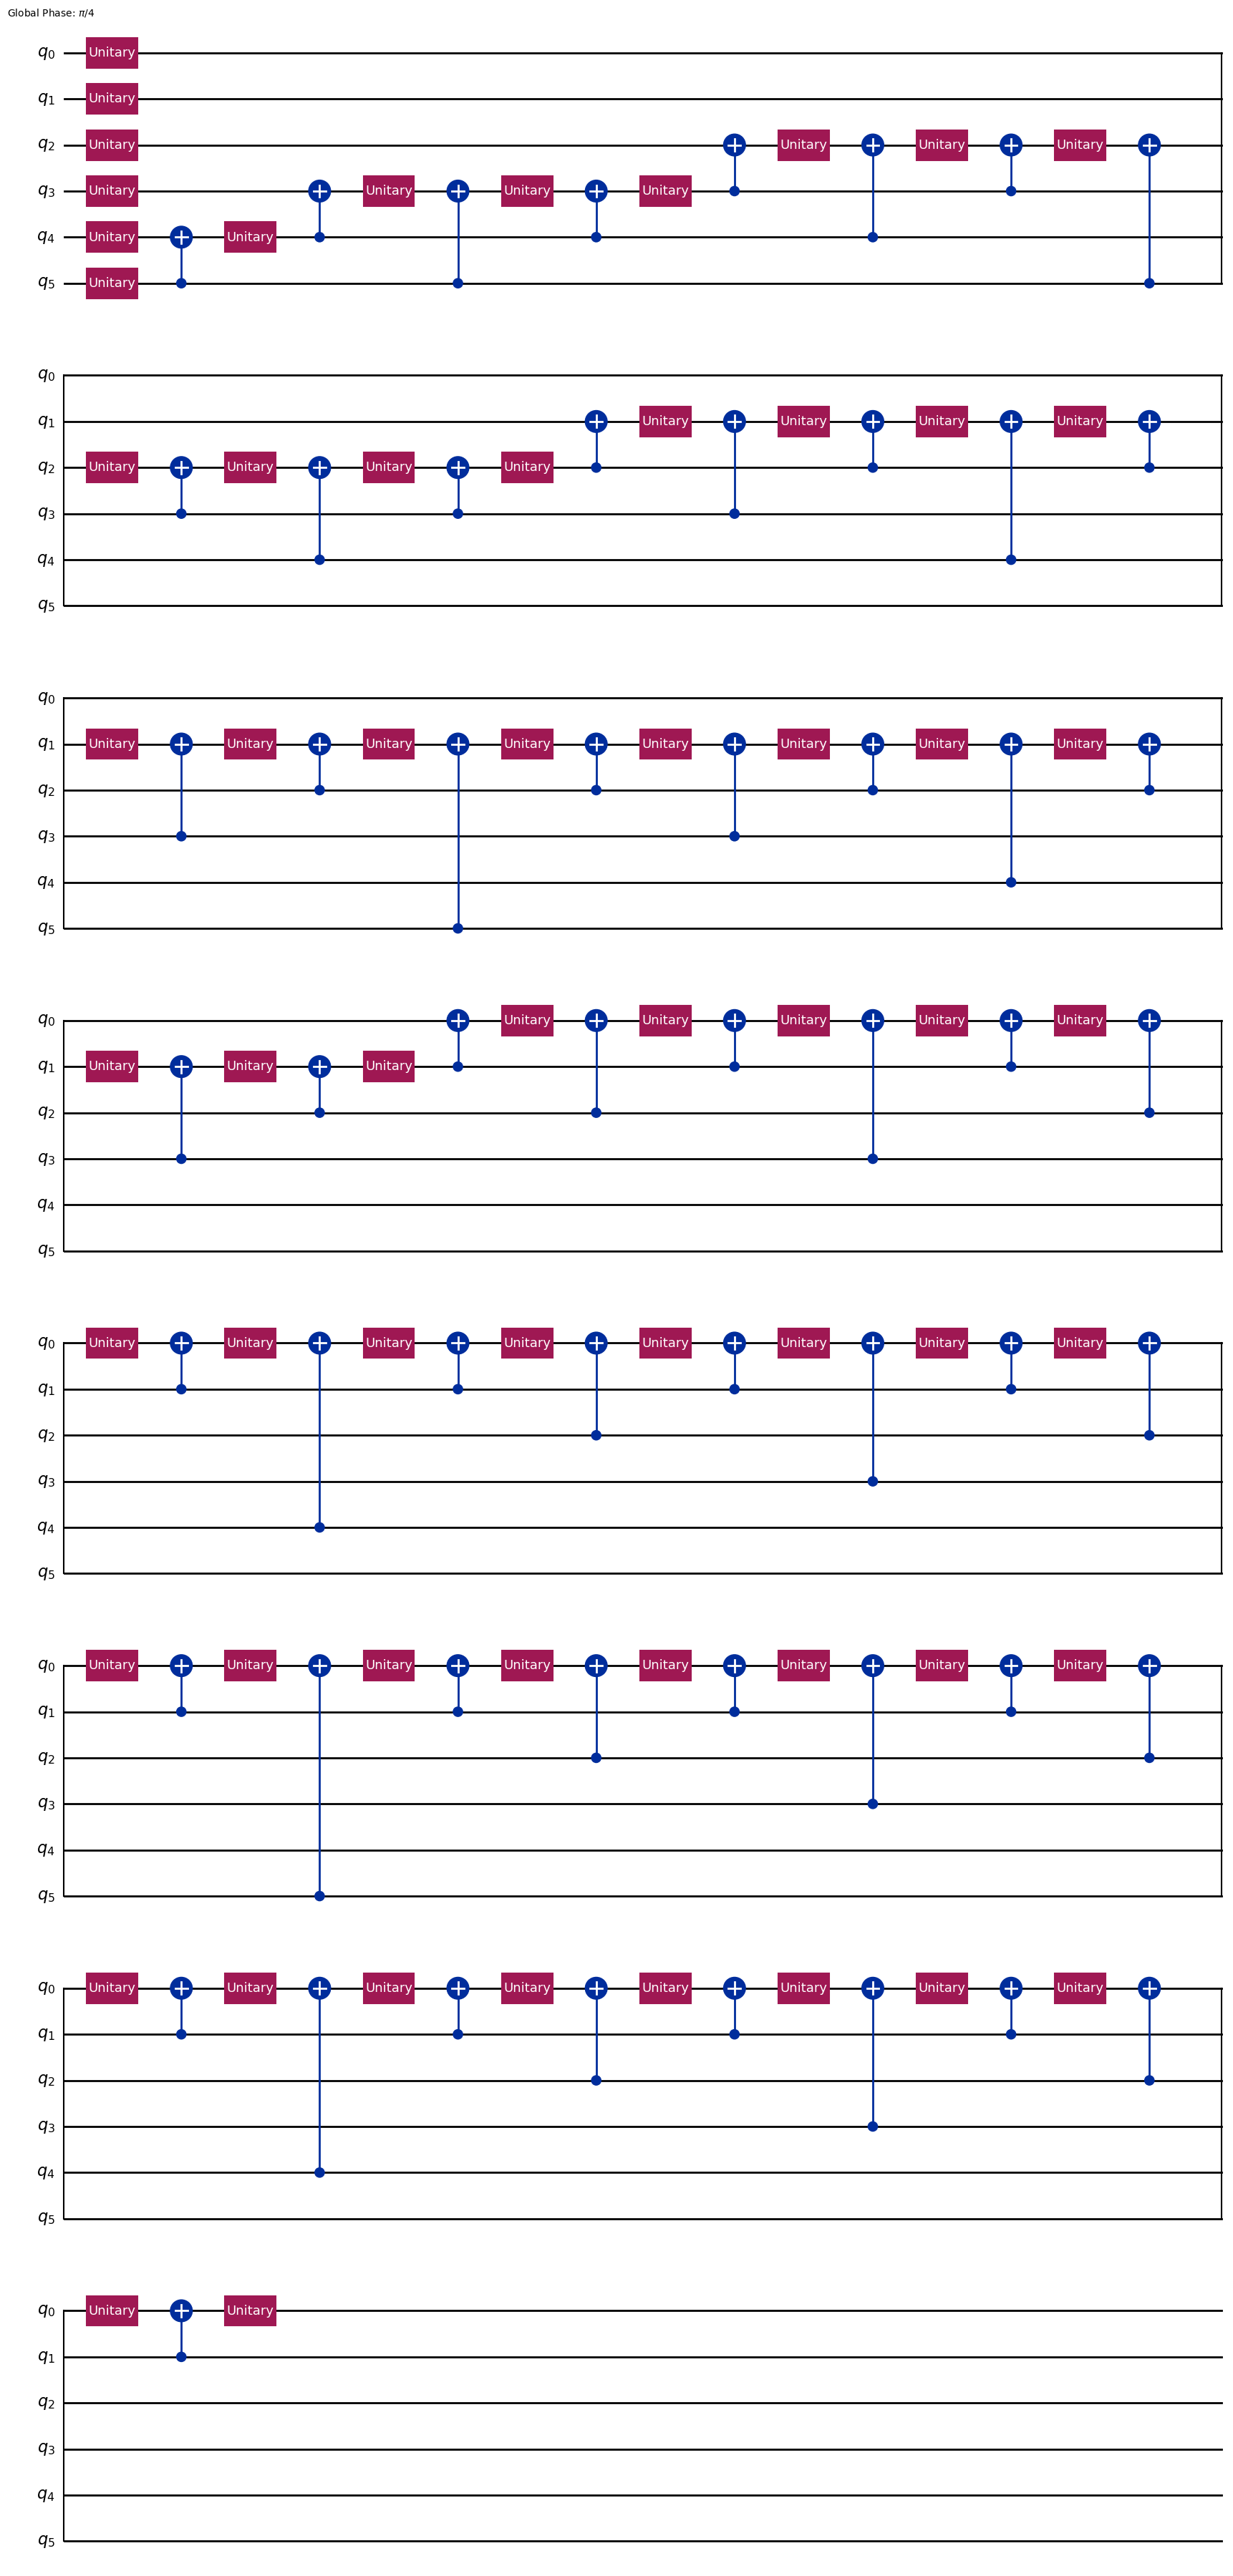

In [24]:
GS = statevector_to_circuit(GS_mat)

GS.draw("mpl")